In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import xarray as xr
import xesmf as xe

import matplotlib.path as mpath
import matplotlib.colors as mcolors
import cartopy


# Regrid LARMIP regions on curvilinear ocean grid (ORCA1)
https://xesmf.readthedocs.io/en/latest/notebooks/Curvilinear_grid.html

## Plotting code

In [2]:
'''Map plotter function that removes the bulk of the code used for plotting from the code where the figure is made.

It takes the following arguments:

data = specific data from a dataset you want to plot, e.g. a selected of the means over a certain period from a larger dataset.
dataset = the full dataset from which data is derived, has to be provided for the corresponding coordinate variables.
ax = must be specified for the arrangement of the subplots in the full figure.
cmin, cmax = specifies the boundary values for the colormap.
titlestring = takes a string in accolades, this becomes the subplot title.

This function also allows to make figures with a split colourbar, and allows to use one single colourbar for all subplots in a figure.'''

def map_plotter(data, lon, lat, ax, cmin, cmax, titlestring): #
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.OCEAN)
    ax.gridlines()
    ax.coastlines()

    # Make circular instead of square plot by setting circular boundaries
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)

    ax.set_boundary(circle, transform=ax.transAxes)
    
    #split colourbar
    colds = plt.cm.Blues(np.linspace(cmin, 0, np.absolute(cmin)*1000)/cmin)
    warms = plt.cm.Reds(np.linspace(0, cmax, cmax*1000)/cmax)

    colors = np.vstack((colds, warms))
    colormap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

    #actual plotting
    im = ax.pcolormesh(lon, lat,
                    data, 
                    cmap=colormap, vmin = cmin, vmax = cmax,
                    transform=ccrs.PlateCarree())
    ax.set_title(titlestring, fontsize = 7*sizemlf)

    return im
    


## Input data

In [3]:
fn_larmip_regions = '/ec/res4/hpcperm/nk0j/ece3data_fwf/masks/LARMIP_regions.nc'
larmip_regions=xr.open_dataset(fn_larmip_regions)
larmip_regions

<xarray.Dataset> Size: 46MB
Dimensions:  (length: 1200, rows: 1200)
Dimensions without coordinates: length, rows
Data variables:
    lon      (length, rows) float64 12MB ...
    lat      (length, rows) float64 12MB ...
    mask     (length, rows) float64 12MB ...
    regions  (length, rows) float64 12MB ...
Attributes:
    history:  Mon Apr 22 14:07:45 2024: ncatted -O -a units,lat,c,c,degrees n...
    NCO:      netCDF Operators version 4.9.7 (Homepage = http://nco.sf.net, C...

In [4]:
ds=larmip_regions
ds['regions']

<xarray.DataArray 'regions' (length: 1200, rows: 1200)> Size: 12MB
[1440000 values with dtype=float64]
Dimensions without coordinates: length, rows

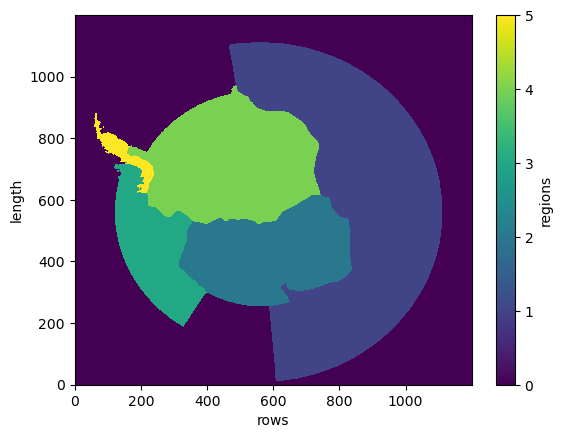

In [5]:
ds.regions.plot.pcolormesh()

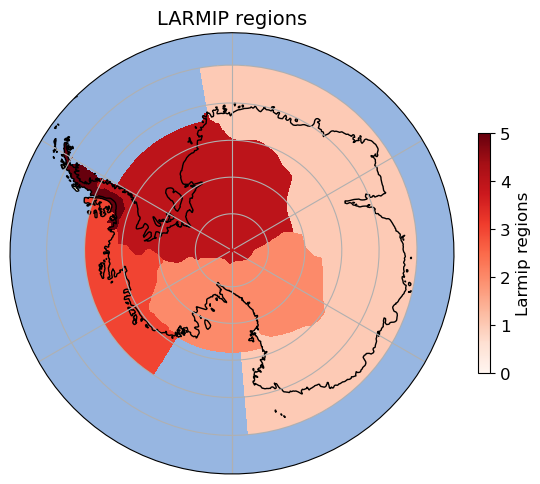

In [6]:
# Plot Antarctic map of LARMIP regions
sizemlf = 2 #size multiplication factor for higher res plots

cmin=0
cmax=5

f = plt.figure(figsize=(6,6))

ax = f.add_axes([0.1, 0.1,0.8, 0.8], projection=ccrs.SouthPolarStereo()) #left, bottom, width, height (range 0 to 1)

im = map_plotter(ds.regions.where(ds.regions), 
            ds.lon, ds.lat, ax, cmin, cmax, 
            'LARMIP regions')

cbar = f.colorbar(im, ax=ax, location='right', fraction =0.025)
cbar.set_label('Larmip regions', fontsize = 12)
cbar.ax.tick_params(labelsize=12)

plt.show()

In [7]:
dr_mask=ds['mask']
dr_mask

<xarray.DataArray 'mask' (length: 1200, rows: 1200)> Size: 12MB
[1440000 values with dtype=float64]
Dimensions without coordinates: length, rows

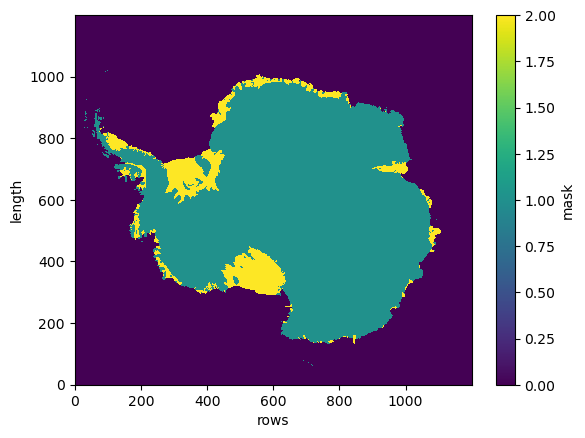

In [8]:
dr_mask.plot.pcolormesh()

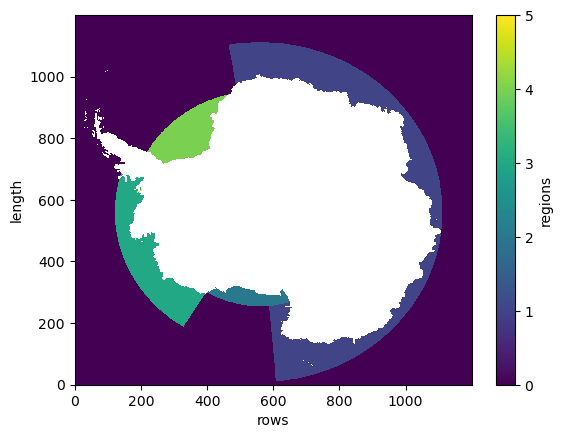

In [9]:
dr_ocean_mask = ds['regions'].where(ds['mask']==0)
dr_ocean_mask.plot.pcolormesh()

In [10]:
dr_ocean_mask

<xarray.DataArray 'regions' (length: 1200, rows: 1200)> Size: 12MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Dimensions without coordinates: length, rows

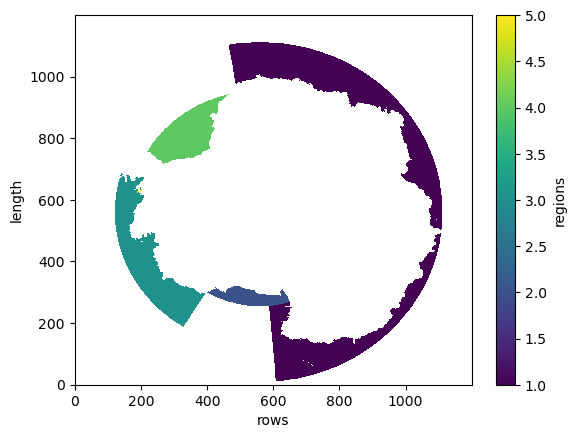

In [11]:
dr_ocean_mask.where(dr_ocean_mask).plot.pcolormesh()

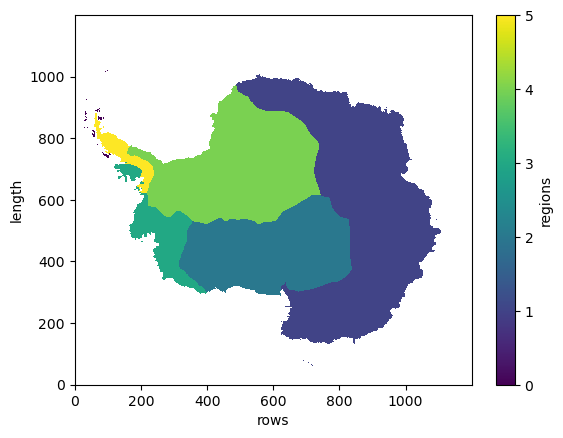

In [12]:
dr_land_mask = ds['regions'].where(ds['mask']!=0)
dr_land_mask.plot.pcolormesh()


## Input grid

In [13]:
#Rename the coordinate names to lon and lat because xESMF has no way to guess variable meaning
ds = ds.assign_coords({'lon':ds.lon,'lat':ds.lat})
ds

<xarray.Dataset> Size: 46MB
Dimensions:  (length: 1200, rows: 1200)
Coordinates:
    lon      (length, rows) float64 12MB -135.0 -135.1 -135.1 ... 44.96 45.0
    lat      (length, rows) float64 12MB -54.67 -54.7 -54.73 ... -50.08 -50.05
Dimensions without coordinates: length, rows
Data variables:
    mask     (length, rows) float64 12MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    regions  (length, rows) float64 12MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    history:  Mon Apr 22 14:07:45 2024: ncatted -O -a units,lat,c,c,degrees n...
    NCO:      netCDF Operators version 4.9.7 (Homepage = http://nco.sf.net, C...

## Output grid

### Ocean

In [14]:
file_nemo = f'/ec/res4/scratch/nk0j/ecearth3-cmip6/tes1/output/nemo/001/tes1_1y_18500101_18501231_opa_grid_T_2D.nc'
ds_nemo=xr.open_dataset(file_nemo)
ds_nemo

<xarray.Dataset> Size: 3MB
Dimensions:    (y: 292, x: 362)
Coordinates:
    nav_lat    (y, x) float32 423kB ...
    nav_lon    (y, x) float32 423kB ...
Dimensions without coordinates: y, x
Data variables:
    areacello  (y, x) float32 423kB ...
    basin      (y, x) float32 423kB ...
    hfgeou     (y, x) float32 423kB ...
    sftof      (y, x) float32 423kB ...
Attributes:
    name:         tes1_1y_18500101_18501231_opa_grid_T_2D
    description:  Created by xios
    title:        Created by xios
    Conventions:  CF-1.6
    timeStamp:    2024-Apr-10 14:12:12 GMT
    uuid:         7646c43d-b017-44d1-a799-c3bd7cd929bb

In [15]:
ds_nemo_out = ds_nemo['nav_lat']
ds_nemo_out = ds_nemo_out.rename({'nav_lon':'lon','nav_lat':'lat'})
ds_nemo_out.name=''
ds_nemo_out

<xarray.DataArray '' (y: 292, x: 362)> Size: 423kB
[105704 values with dtype=float32]
Coordinates:
    lat      (y, x) float32 423kB ...
    lon      (y, x) float32 423kB ...
Dimensions without coordinates: y, x
Attributes:
    standard_name:  latitude
    long_name:      Latitude
    units:          degrees_north

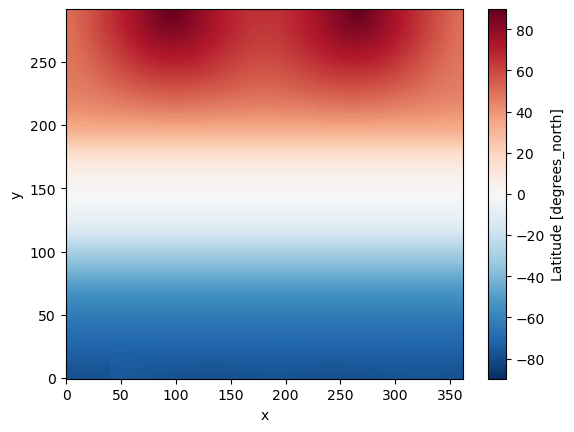

In [16]:
ds_nemo_out.plot.pcolormesh()

### Atmosphere

In [17]:
file_ifs = f'/ec/res4/hpcperm/nm6/ece3data/runoff-mapper/runoff_maps.nc'
ds_ifs=xr.open_dataset(file_ifs)
ds_ifs


<xarray.Dataset> Size: 2MB
Dimensions:            (lon: 512, lat: 256)
Coordinates:
  * lon                (lon) float64 4kB 0.0 0.7031 1.406 ... 357.9 358.6 359.3
  * lat                (lat) float64 2kB -89.46 -88.77 -88.07 ... 88.77 89.46
Data variables:
    drainage_basin_id  (lat, lon) int32 524kB ...
    arrival_point_id   (lat, lon) int32 524kB ...
    calving_point_id   (lat, lon) int32 524kB ...
Attributes:
    ece-origin:  Klaus Wyser (SMHI) for EC-Earth

In [18]:
ds_ifs_out = ds_ifs['drainage_basin_id']
ds_ifs_out


<xarray.DataArray 'drainage_basin_id' (lat: 256, lon: 512)> Size: 524kB
[131072 values with dtype=int32]
Coordinates:
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
  * lat      (lat) float64 2kB -89.46 -88.77 -88.07 -87.37 ... 88.07 88.77 89.46

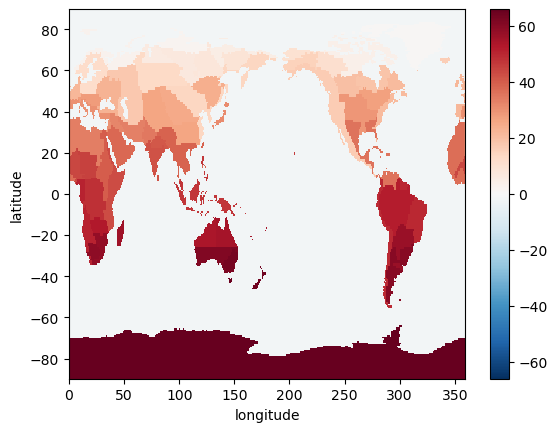

In [19]:
ds_ifs_out.name=''
ds_ifs_out.plot.pcolormesh()

## Perform regridding

### Ocean

In [20]:
regridder_nemo = xe.Regridder(ds.regions, ds_nemo_out, "bilinear")
regridder_nemo #print basic regridder information

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_1200x1200_292x362.nc 
Reuse pre-computed weights? False 
Input grid shape:           (1200, 1200) 
Output grid shape:          (292, 362) 
Periodic in longitude?      False

In [21]:
dr_ocean_mask_out = regridder_nemo(dr_ocean_mask)

In [22]:
dr_ocean_mask_out

<xarray.DataArray (y: 292, x: 362)> Size: 846kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])
Coordinates:
    lat      (y, x) float32 423kB -78.39 -78.39 -78.39 ... 50.23 50.01 50.01
    lon      (y, x) float32 423kB 72.5 73.5 74.5 75.5 ... 73.05 73.04 73.0 72.99
Dimensions without coordinates: y, x
Attributes:
    regrid_method:  bilinear

In [23]:
dr_ocean_mask_out.name = 'regions'
ds_ocean_mask_out = dr_ocean_mask_out.to_dataset()
ds_ocean_mask_out

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 292, x: 362)
Coordinates:
    lat      (y, x) float32 423kB -78.39 -78.39 -78.39 ... 50.23 50.01 50.01
    lon      (y, x) float32 423kB 72.5 73.5 74.5 75.5 ... 73.05 73.04 73.0 72.99
Dimensions without coordinates: y, x
Data variables:
    regions  (y, x) float64 846kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 0.0

In [24]:
ds_ocean_mask_out.to_netcdf('/ec/res4/hpcperm/nk0j/ece3data_fwf/masks/LARMIP_ocean_regions_ORCA1.nc')

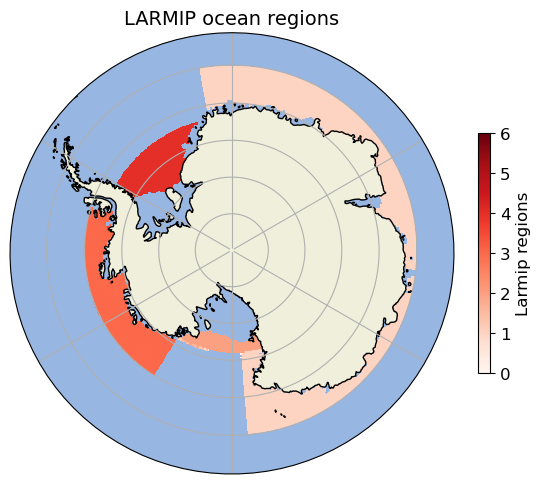

In [25]:
# Plot Antarctic map of LARMIP regions
sizemlf = 2 #size multiplication factor for higher res plots

cmin=0
cmax=6

f = plt.figure(figsize=(6,6))

ax = f.add_axes([0.1, 0.1,0.8, 0.8], projection=ccrs.SouthPolarStereo()) #left, bottom, width, height (range 0 to 1)

im = map_plotter(dr_ocean_mask_out.where(dr_ocean_mask_out), 
            dr_ocean_mask_out.lon, dr_ocean_mask_out.lat, ax, cmin, cmax, 
            'LARMIP ocean regions')

cbar = f.colorbar(im, ax=ax, location='right', fraction =0.025)
cbar.set_label('Larmip regions', fontsize = 12)
cbar.ax.tick_params(labelsize=12)

plt.show()

### Atmosphere

In [26]:
regridder_ifs = xe.Regridder(ds.regions, ds_ifs_out, "bilinear")
regridder_ifs #print basic regridder information

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_1200x1200_256x512.nc 
Reuse pre-computed weights? False 
Input grid shape:           (1200, 1200) 
Output grid shape:          (256, 512) 
Periodic in longitude?      False

In [27]:
dr_land_mask_out = regridder_ifs(dr_land_mask)

In [28]:
dr_land_mask_out

<xarray.DataArray (lat: 256, lon: 512)> Size: 1MB
array([[4., 4., 4., ..., 4., 4., 4.],
       [4., 4., 4., ..., 4., 4., 4.],
       [4., 4., 4., ..., 4., 4., 4.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
  * lat      (lat) float64 2kB -89.46 -88.77 -88.07 -87.37 ... 88.07 88.77 89.46
Attributes:
    regrid_method:  bilinear

In [29]:
dr_land_mask_out.name = 'regions'
ds_land_mask_out = dr_land_mask_out.to_dataset()
ds_land_mask_out

<xarray.Dataset> Size: 1MB
Dimensions:  (lon: 512, lat: 256)
Coordinates:
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
  * lat      (lat) float64 2kB -89.46 -88.77 -88.07 -87.37 ... 88.07 88.77 89.46
Data variables:
    regions  (lat, lon) float64 1MB 4.0 4.0 4.0 4.0 4.0 ... 0.0 0.0 0.0 0.0 0.0

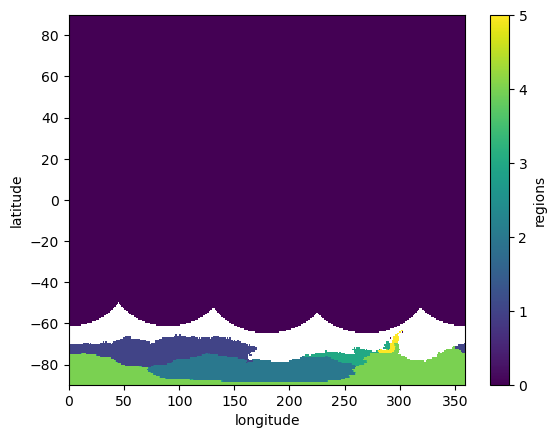

In [30]:
ds_land_mask_out.regions.plot.pcolormesh()

In [31]:
ds_land_mask_out.to_netcdf('/ec/res4/hpcperm/nk0j/ece3data_fwf/masks/LARMIP_landice_regions_T255.nc')

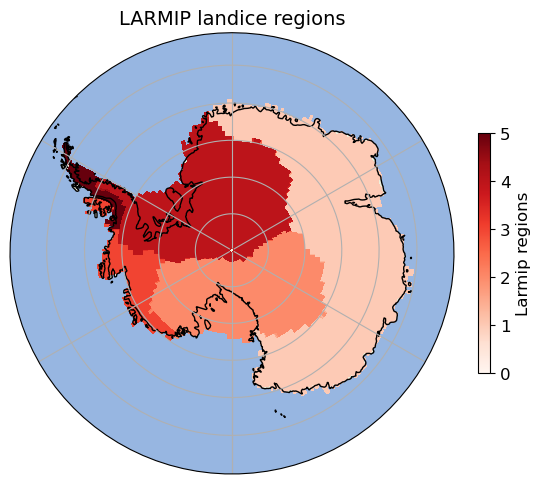

In [32]:
# Plot Antarctic map of LARMIP regions
sizemlf = 2 #size multiplication factor for higher res plots

cmin=0
cmax=5

f = plt.figure(figsize=(6,6))

ax = f.add_axes([0.1, 0.1,0.8, 0.8], projection=ccrs.SouthPolarStereo()) #left, bottom, width, height (range 0 to 1)

im = map_plotter(dr_land_mask_out.where(dr_land_mask_out), 
            dr_land_mask_out.lon, dr_land_mask_out.lat, ax, cmin, cmax, 
            'LARMIP landice regions')

cbar = f.colorbar(im, ax=ax, location='right', fraction =0.025)
cbar.set_label('Larmip regions', fontsize = 12)
cbar.ax.tick_params(labelsize=12)

plt.show()